### Introduction

This notebook demonstrates how to fit a simple finite element interpolated neural network (FEINN) to an inverse problem with sparse, noisy measurements.

### Setup

First, activate the environment and load the required libraries.

In [1]:
using Pkg
Pkg.activate("../")

using FiniteElementChains
using Gridap
using Flux
using Gridap.FESpaces
using Gridap.ReferenceFEs
using Gridap.Arrays
using Gridap.Geometry
using Gridap.Fields
using Gridap.CellData
using Gridap.Algebra
using Zygote
using LinearAlgebra
using ForwardDiff
using Distributions
using ChainRules
using Plots
using DelimitedFiles
using Optim

  Activating project at `~/Documents/FiniteElementChains.jl`


Next, we'll set up our test solution. For this problem, the true state and diffusion coefficient are given by:

\begin{equation}
    u(x,y) = sin(\pi x)sin(\pi y),\ \kappa (x) = \frac{1}{1 + x^2 + y^2 + (x-1)^2 + (y-1)^2}
\end{equation}

The underlying physics are represented by the variable coefficient poisson equation:

\begin{equation}
    \nabla \cdot (\kappa (x,y) \nabla u(x,y)) = f(x,y)
\end{equation}

The domain is given by $[0,1]^2$ and is split into 50x50 quadrilaterals. This is the problem used in section 6.2.2 of Badia et al (2024).

For this problem, we'll assume we can observe the true state at 64 points inside the domain, contaminated with Gaussian noise. This is analogous to evenly spaced thermocouples.

In [3]:
## Manufactured solution for a variable coefficient poisson problem
u(x) = sin(pi*x[1])*sin(pi*x[2])
kappa(x) = 1/(1 + x[1]^2 + x[2]^2 + (x[1] - 1)^2 + (x[2] - 1)^2)

grad_u(x) = ForwardDiff.gradient(u, x)
grad_u(x::VectorValue{2, Float64}) = ForwardDiff.gradient(u, get_array(x))

grad_kappa(x) = ForwardDiff.gradient(kappa, x)
grad_kappa(x::VectorValue{2, Float64}) = ForwardDiff.gradient(kappa, get_array(x))

lap_u(x) = ForwardDiff.gradient(j -> grad_u(j)[1], x)[1] + ForwardDiff.gradient(j -> grad_u(j)[2], x)[2]
lap_u(x::VectorValue{2, Float64}) = ForwardDiff.gradient(j -> grad_u(j)[1], get_array(x))[1] + ForwardDiff.gradient(j -> grad_u(j)[2], get_array(x))[2]

f_s(x) =  -1.0* (grad_kappa(x) ⋅ grad_u(x) +  kappa(x) * lap_u(x))


f_s (generic function with 1 method)

Below, we'll set up our problem using Gridap. Notice we instantiate spaces for both $\kappa (x)$, and for $u (x)$.

In [4]:
# set up Gridap Model
order = 1
domain = (0,1,0,1)
partition = (50,50)
model = CartesianDiscreteModel(domain,partition)

reffe = ReferenceFE(lagrangian,Float64,order)

degree = 2
Ω = Triangulation(model)
dΩ = Measure(Ω,degree)

# set up for the u function

V0 = TestFESpace(model,reffe,conformity=:H1,dirichlet_tags="boundary")
U = TrialFESpace(V0,u)
assem = SparseMatrixAssembler(U,V0)

# set up for the kappa function
V2 = TestFESpace(model,reffe,conformity=:H1)
U_kap = TrialFESpace(V2)
assem_k = SparseMatrixAssembler(U_kap,V2)

# set up overall problem
v_fef = get_fe_basis(V0)
resfunc(k,u,v) = ∫(k*( ∇(v)⋅∇(u) ))*dΩ - ∫( v*f_s )*dΩ
resfunc_ku(k,u) = resfunc(k,u,v_fef)

resfunc_ku (generic function with 1 method)

Now, let's extract 64 sensor locations, predict their true values, and contaminate those with gaussian noise.

In [5]:
# extract 64 sensor locations, assign them a gaussian noise sensor reading
newarrarr = rand(49,49)
newarrind = collect(1:2401)
for i in eachindex(newarrarr)
    newarrarr[i] = newarrind[i]
end
known_coord_ids = vec([Int(i) for i in newarrarr[[3,9,15,21,27,33,39,45],[3,9,15,21,27,33,39,45]]])

known_coords = Ω.grid.node_coords[2:(end-1),2:(end-1)][known_coord_ids]
known_values = u.(known_coords) .+ rand(Normal(0,0.05), length(known_coords))

# set interior and all nodes
interior_coords = [get_array(i) for i in Ω.grid.node_coords[2:(end-1),2:(end-1)]]
all_coords = [get_array(i) for i in Ω.grid.node_coords]

51×51 Matrix{StaticArraysCore.SVector{2, Float64}}:
 [0.0, 0.0]   [0.0, 0.02]   [0.0, 0.04]   …  [0.0, 0.98]   [0.0, 1.0]
 [0.02, 0.0]  [0.02, 0.02]  [0.02, 0.04]     [0.02, 0.98]  [0.02, 1.0]
 [0.04, 0.0]  [0.04, 0.02]  [0.04, 0.04]     [0.04, 0.98]  [0.04, 1.0]
 [0.06, 0.0]  [0.06, 0.02]  [0.06, 0.04]     [0.06, 0.98]  [0.06, 1.0]
 [0.08, 0.0]  [0.08, 0.02]  [0.08, 0.04]     [0.08, 0.98]  [0.08, 1.0]
 [0.1, 0.0]   [0.1, 0.02]   [0.1, 0.04]   …  [0.1, 0.98]   [0.1, 1.0]
 [0.12, 0.0]  [0.12, 0.02]  [0.12, 0.04]     [0.12, 0.98]  [0.12, 1.0]
 [0.14, 0.0]  [0.14, 0.02]  [0.14, 0.04]     [0.14, 0.98]  [0.14, 1.0]
 [0.16, 0.0]  [0.16, 0.02]  [0.16, 0.04]     [0.16, 0.98]  [0.16, 1.0]
 [0.18, 0.0]  [0.18, 0.02]  [0.18, 0.04]     [0.18, 0.98]  [0.18, 1.0]
 [0.2, 0.0]   [0.2, 0.02]   [0.2, 0.04]   …  [0.2, 0.98]   [0.2, 1.0]
 [0.22, 0.0]  [0.22, 0.02]  [0.22, 0.04]     [0.22, 0.98]  [0.22, 1.0]
 [0.24, 0.0]  [0.24, 0.02]  [0.24, 0.04]     [0.24, 0.98]  [0.24, 1.0]
 ⋮                          

Finally, let's instantiate the structs that will be used to fit our FEINN.

In [6]:
U_kap_coords = get_coord_mat(all_coords)
U_u_coords = get_coord_mat(interior_coords)

cell_ids_field = get_cell_ids_field(Ω)
dofmap = get_dof_map(U,cell_ids_field,known_coords)

pdesetup = PDESetup(U,U_kap,assem,assem_k,U_u_coords,U_kap_coords)
sensordata = SensorData(known_values,known_coords,dofmap)
nnsetup = initialize_networks()

NNSetup{Optimisers.Restructure{Chain{Tuple{Dense{typeof(softplus), Matrix{Float32}, Vector{Float32}}, Dense{typeof(softplus), Matrix{Float32}, Vector{Float32}}, Dense{typeof(identity), Matrix{Float32}, Vector{Float32}}}}, @NamedTuple{layers::Tuple{@NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}, @NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}, @NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}}}}, Optimisers.Restructure{Chain{Tuple{Dense{typeof(softplus), Matrix{Float32}, Vector{Float32}}, Dense{typeof(softplus), Matrix{Float32}, Vector{Float32}}, Dense{typeof(FiniteElementChains.rect_abs), Matrix{Float32}, Vector{Float32}}}}, @NamedTuple{layers::Tuple{@NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}, @NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}, @NamedTuple{weight::Int64, bias::Int64, σ::Tuple{}}}}}, Vector{Float32}}(Restructure(Chain, ..., 501), Restructure(Chain, ..., 501), Float32[0.26514792, 0.088023245, -0.23067695, 0.11638146, 0.43184048, 0.3688315, -0.3115087

### Training the models

To train the FEINN, simply call train_feinn!. This will modify the parameters in `nnsetup` in place. The models are trained using BFGS and Optim.jl. See Batia et al (2024) for more information on how these models are trained.

In [7]:
train_feinn!([300,100,300], [1.0,3.0], resfunc_ku, nnsetup, pdesetup, sensordata)

Training on error...

┌ Warning: Layer with Float32 parameters got Float64 input.
│   The input will be converted, but any earlier layers may be very slow.
│   layer = Dense(2 => 20, softplus)  # 60 parameters
│   summary(x) = "2×2401 Matrix{Float64}"
└ @ Flux ~/.julia/packages/Flux/hrg9M/src/layers/stateless.jl:60


Training on FEM residual...Training on residual and error with alpha = 1.0 ...Training on residual and error with alpha = 3.0 ...

### Evaluation

Now, let's evaluate the results. First, we'll take the $L^2(\Omega)$ norm of the prediction error for $u (x)$. Then, we'll plot the predicted results for both $u$ and $\kappa$.

In [10]:
upredfunc, _ = get_predictions(nnsetup.re_u,nnsetup.θ_u, U_u_coords,U)
kpredfunc, _ = get_predictions(nnsetup.re_k,nnsetup.θ_k, U_kap_coords,U_kap)
e = u - upredfunc
el2 = sqrt(sum( ∫( e*e )*dΩ ))

0.009208885299490939

In [27]:
nx, ny = 100, 100
xs = range(0, 1, length=nx)
ys = range(0, 1, length=ny)

dx = xs[2]-xs[1]
dy = ys[2]-ys[1]

xedges = range(xs[1]-dx/2, xs[end]+dx/2, length=nx+1)
yedges = range(ys[1]-dy/2, ys[end]+dy/2, length=ny+1)

function heatmap_feinn(xedges,yedges,err,title)
    p = heatmap(
        xedges,
        yedges,
        err,
        aspect_ratio=:equal,
        xlims=(0,1),
        ylims=(0,1),
        c=:hsv,
        xlabel="x",
        ylabel="y",
        title=title,
        size=(400,400),
        margin=5Plots.mm,
        grid=false
    )
    return p
end

100×100 Matrix{Float64}:
 0.0509868  0.0507988  0.0505385  …  0.0638865  0.0649475  0.0660191
 0.0506761  0.0505345  0.0503201     0.0609367  0.0619774  0.0630289
 0.0503     0.0502048  0.0500364     0.0580712  0.059092   0.0601243
 0.0498595  0.0498107  0.0496878     0.0552886  0.0562899  0.0573035
 0.0493554  0.049353   0.0492758     0.0525884  0.0535706  0.0545664
 0.0487892  0.0488327  0.0488011  …  0.0499688  0.0509333  0.0519117
 0.0481614  0.0482511  0.048265      0.0474295  0.0483766  0.0493389
 0.0474732  0.0476091  0.0476685     0.0449694  0.0459001  0.0468466
 0.0467262  0.0469078  0.0470127     0.0425875  0.0435024  0.0444342
 0.0459209  0.0461488  0.046299      0.0402829  0.0411827  0.0421001
 0.0450591  0.0453324  0.0455283  …  0.0380543  0.0389403  0.0398442
 0.0441413  0.0444606  0.0447018     0.0359009  0.0367734  0.0376652
 0.0431694  0.0435345  0.0438211     0.0338215  0.0346812  0.0355618
 ⋮                                ⋱                        
 0.110646   0.1069

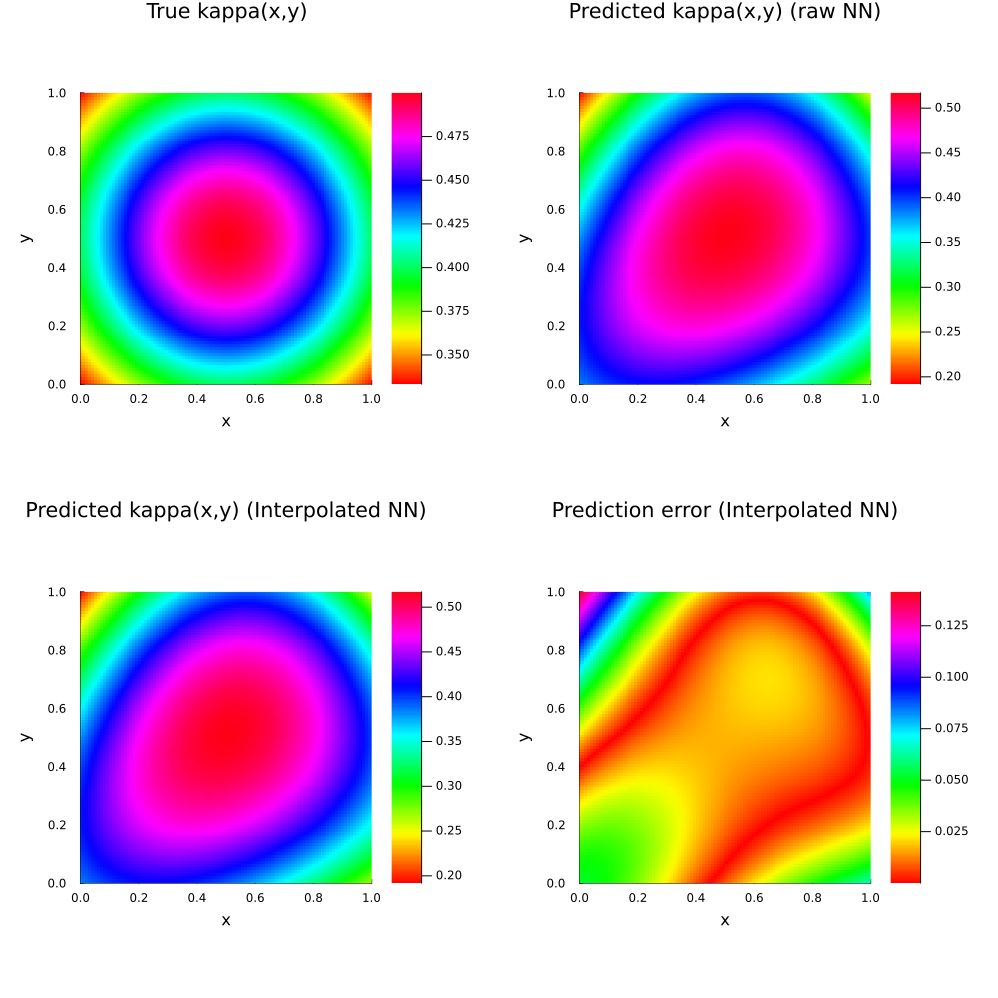

In [50]:
kpred_nn = [nnsetup.re_k(nnsetup.θ_k)([x,y])[1] for y in ys, x in xs]
kpred_feinn = [nnsetup.re_k(nnsetup.θ_k)([x,y])[1] for y in ys, x in xs]
ktrue = [kappa([x,y]) for y in ys, x in xs]
kerr = [abs(kappa([x,y]) - nnsetup.re_k(nnsetup.θ_k)([x,y])[1]) for y in ys, x in xs]

p1 = heatmap_feinn(xedges,yedges,ktrue,"True kappa(x,y)")
p2 = heatmap_feinn(xedges,yedges,kpred_nn,"Predicted kappa(x,y) (raw NN)")
p3 = heatmap_feinn(xedges,yedges,kpred_feinn,"Predicted kappa(x,y) (Interpolated NN)")
p4 = heatmap_feinn(xedges,yedges,kerr,"Prediction error (Interpolated NN)")

p = plot(p1, p2, p3,p4, layout=(1,4))

# display("text/html", """
# <div style="text-align:center">
# $(repr(MIME("image/svg+xml"), p))
# </div>
# """)

p = plot(
    p1, p2, p3, p4,
    layout=(2,2),
    size=(1000, 1000)
)

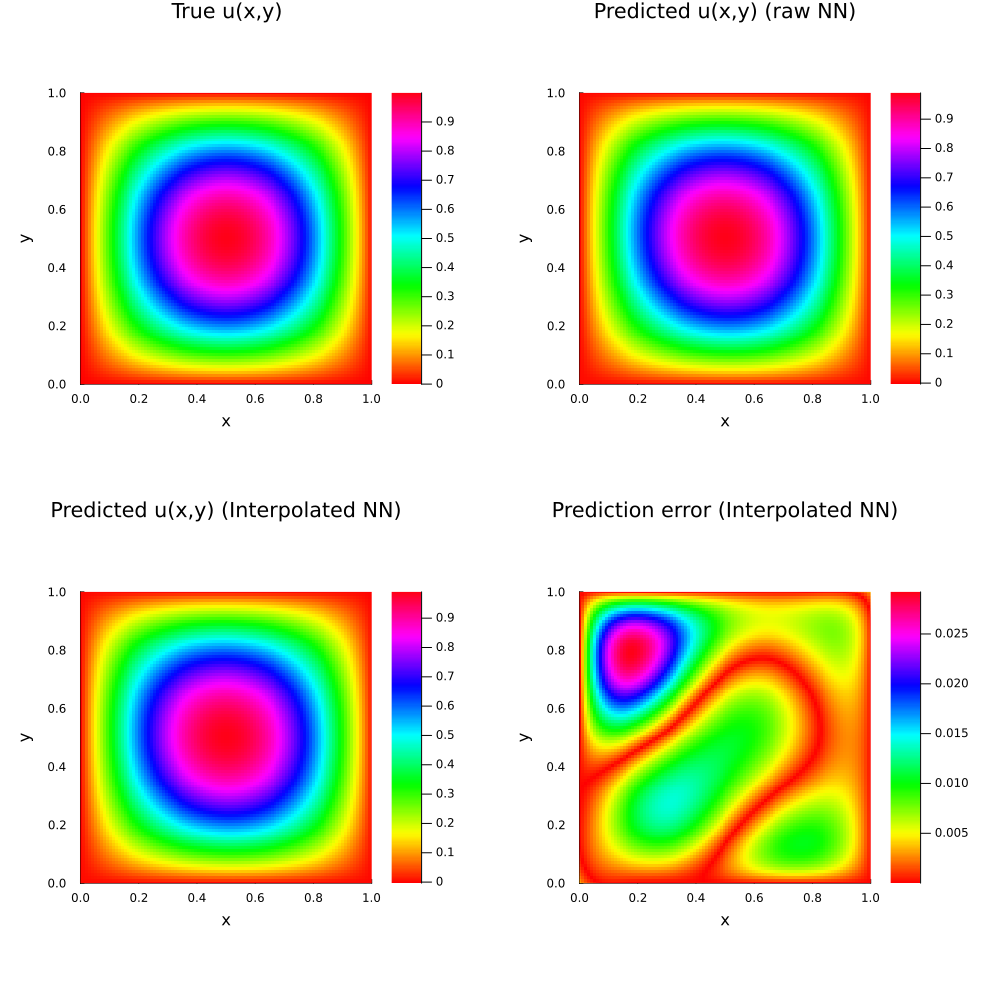

In [53]:
upred_nn = [nnsetup.re_u(nnsetup.θ_u)([x,y])[1] for y in ys, x in xs]
upred_feinn = [nnsetup.re_u(nnsetup.θ_u)([x,y])[1] for y in ys, x in xs]
utrue = [u([x,y]) for y in ys, x in xs]
uerr = [abs(u([x,y]) - nnsetup.re_u(nnsetup.θ_u)([x,y])[1]) for y in ys, x in xs]

p1 = heatmap_feinn(xedges,yedges,utrue,"True u(x,y)")
p2 = heatmap_feinn(xedges,yedges,upred_nn,"Predicted u(x,y) (raw NN)")
p3 = heatmap_feinn(xedges,yedges,upred_feinn,"Predicted u(x,y) (Interpolated NN)")
p4 = heatmap_feinn(xedges,yedges,uerr,"Prediction error (Interpolated NN)")

p = plot(
    p1, p2, p3, p4,
    layout=(2,2),
    size=(1000, 1000)
)

### Citations

[1] S. Badia, W. Li, and A. F. Martín. “Finite element interpolated neural networks for solving forward
and inverse problems”. In: Computer Methods in Applied Mechanics and Engineering 418 (2024),
p. 116505. doi: 10.1016/j.cma.2023.116505.